In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import logging
import warnings
import pandas as pd

def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(42)

In [2]:
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger('tensorflow').setLevel(logging.ERROR)

In [3]:
# --- 3. LOAD DATA ---
TRAIN_FILE = 'water_quality_train.csv'
TEST_FILE = 'water_quality_test.csv'
TARGET_COL = 'TDS'

print("Loading Data...")
df_train = pd.read_csv(TRAIN_FILE)
df_test = pd.read_csv(TEST_FILE)

Loading Data...


In [4]:
df_train.head()

,sno,district,mandal,village,lat_gis,long_gis,gwl,season,Unnamed: 8,pH,...,SO4,Na,K,Ca,Mg,T.H,SAR,Classification,RSC meq / L,Classification.1
0,3,ADILABAD,Gudihatnoor,Gudihatnoor,19.525555,78.512222,5.050000,Post-monsoon 2020,NaN,8.21,...,10.50000,65.000000,3.000000,16.000000,48.620000,239.917763,1.824544,C2S1,0.001645,P.S.
1,641,BHUPALPALLY,Nakrekal,Ootla,18.518850,80.188077,6.503192,Post-monsoon 2020,NaN,7,...,72.69309,130.706583,2.940955,30.765904,0.000000,55.493044,3.805094,C2S1,5.059215,P.S.
2,189,NALGONDA,Anumula,Rajavaram,16.680160,79.407512,6.030000,Post-monsoon 2020,NaN,7.57,...,32.00000,104.610000,0.400000,136.000000,38.896000,499.934211,2.034178,C3S1,-2.998684,P.S.
3,746,HYDERABAD,Thurkapally,Velgatur,17.979753,78.665689,2.575817,Post-monsoon 2020,NaN,7.78,...,31.43227,0.000000,26.635082,20.837898,93.179048,434.636989,0.000000,C4S1,-7.990459,P.S.
4,483,NIRMAL,Vikarabad,Jainath,16.136313,78.701507,3.296184,Post-monsoon 2020,NaN,8.12,...,0.00000,122.657511,10.388645,106.805107,22.075274,359.848585,3.973184,C4S2,1.507511,P.S.


In [5]:
df_test.head()

,sno,district,mandal,village,lat_gis,long_gis,gwl,season,Unnamed: 8,pH,...,SO4,Na,K,Ca,Mg,T.H,SAR,Classification,RSC meq / L,Classification.1
0,759,KHAMMAM,Gambhiraopet,Juvinile home,16.907893,79.726787,7.208308,Post-monsoon 2020,NaN,8.01,...,44.443637,143.868374,0.000000,33.046787,47.631636,279.640343,4.334885,C3S1,1.328789,P.S.
1,884,YADADRI,Sircilla,Pasra,18.255137,79.687699,1.364329,Post-monsoon 2020,NaN,7.6,...,146.761559,189.923315,9.905630,70.226422,67.131050,452.610708,3.367661,C4S2,-3.987144,P.S.
2,142,MEDAK,Chegunta,Chegunta,17.934100,78.518600,5.550000,Post-monsoon 2020,NaN,7.54,...,9.000000,104.570000,3.180000,64.000000,29.172000,279.950658,2.717306,C3S1,1.200987,P.S.
3,99,KHAMMAM,Khammam(U),Khammam I,17.233300,80.133300,0.500000,Post-monsoon 2020,NaN,7.02,...,9.500000,56.000000,3.470000,24.000000,19.448000,139.967105,2.058009,C2S1,0.800658,P.S.
4,1013,SURYAPET,Alwal,Chinnaporla,19.058317,78.770412,1.442218,Post-monsoon 2020,NaN,7.29,...,0.000000,103.579236,29.425401,0.000000,0.000000,0.000000,5.193200,C2S1,9.038249,P.S.


In [6]:
cols_to_drop = ['sno', 'district', 'mandal', 'village', 'season', 
                'Unnamed: 8', 'Classification', 'Classification.1']
numeric_cols = df_train.select_dtypes(include=['float64', 'int64']).columns
feature_cols = [c for c in numeric_cols if c not in cols_to_drop and c != TARGET_COL]

X_train = df_train[feature_cols].values
y_train = df_train[TARGET_COL].values
X_test = df_test[feature_cols].values
y_test = df_test[TARGET_COL].values

In [7]:
# Handle Missing Values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [8]:
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1))

In [9]:
X_train_reshaped = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_reshaped = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

In [10]:
def add_micro_noise(data, noise_factor=0.015): 
    # Use the same seed inside the function too
    np.random.seed(42) 
    noise = np.random.normal(loc=0.0, scale=noise_factor, size=data.shape)
    return data + noise

print("Applying Locked 1.5% Noise...")
X_train_stabilized = add_micro_noise(X_train_reshaped, noise_factor=0.015)

Applying Locked 1.5% Noise...


In [11]:
# --- 6. BUILD MODEL ---
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dropout, Dense
from tensorflow.keras.optimizers import Adam
model = Sequential()
model.add(GRU(64, return_sequences=False, input_shape=(1, len(feature_cols))))
model.add(Dropout(0.25)) # 25% Dropout
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

In [12]:
# --- 7. TRAIN (100 Epochs) ---
print("Starting Locked Training...")
history = model.fit(
    X_train_stabilized, y_train_scaled,
    epochs=100,
    batch_size=16,
    validation_data=(X_test_reshaped, y_test_scaled),
    verbose=1,
    shuffle=False 
)

Starting Locked Training...
Epoch 1/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.0050 - val_loss: 0.0012
Epoch 2/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0014 - val_loss: 2.9788e-04
Epoch 3/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.3442e-04 - val_loss: 3.4757e-04
Epoch 4/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.6316e-04 - val_loss: 2.2771e-04
Epoch 5/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.3414e-04 - val_loss: 2.5058e-04
Epoch 6/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.8203e-04 - val_loss: 1.3952e-04
Epoch 7/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.5656e-04 - val_loss: 1.2744e-04
Epoch 8/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.1727e-04 - val_loss: 1.8323e-04
Epoch 9/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.0918e-04 - val_loss: 1.1957e-04
Epoch 10/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.1446e-04 - val_loss: 1.5576e-04
Epoch 11/100
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

In [13]:
# --- 8. RESULTS ---
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
preds_scaled = model.predict(X_test_reshaped)
predictions = scaler_y.inverse_transform(preds_scaled)
y_actual = scaler_y.inverse_transform(y_test_scaled)

r2 = r2_score(y_actual, predictions)
rmse = np.sqrt(mean_squared_error(y_actual, predictions))
mae = mean_absolute_error(y_actual, predictions)

print("\n" + "="*30)
print(f" FINAL  RESULTS")
print(f" R2 Score: {r2:.4f}") 
print(f" RMSE:     {rmse:.2f}")
print(f" MAE:      {mae:.2f}")
print("="*30 + "\n")

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step

 FINAL  RESULTS
 R2 Score: 0.9933
 RMSE:     48.01
 MAE:      35.80



In [14]:
# Save
import joblib
model.save('water_quality_model.keras')
joblib.dump(scaler_X, 'scaler_X.pkl')
joblib.dump(scaler_y, 'scaler_Y.pkl')
print("Model Saved.")

Model Saved.


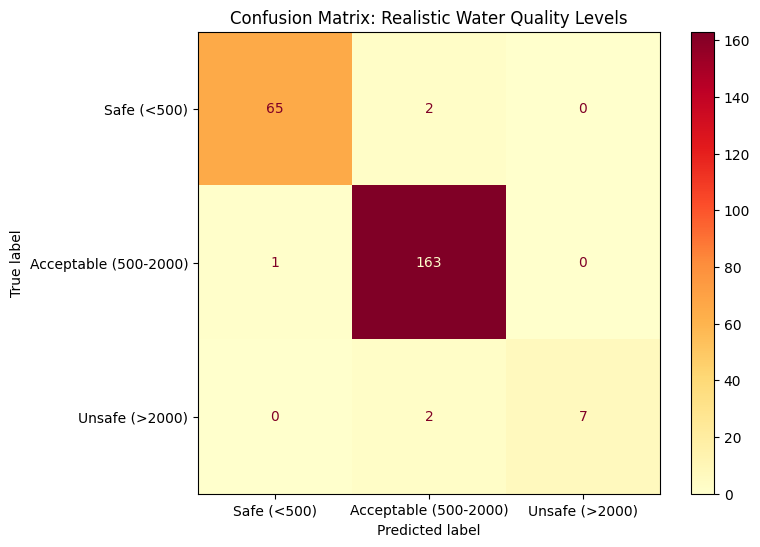


 REALISTIC CLASSIFICATION REPORT
                       precision    recall  f1-score   support

          Safe (<500)       0.98      0.99      0.98       164
Acceptable (500-2000)       0.98      0.97      0.98        67
       Unsafe (>2000)       1.00      0.78      0.88         9

             accuracy                           0.98       240
            macro avg       0.99      0.91      0.95       240
         weighted avg       0.98      0.98      0.98       240



In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

# --- 1. Define Realistic Classification Logic ---
def get_real_status(tds):
    if tds < 500:
        return "Safe (<500)"       
    elif tds <= 2000:
        return "Acceptable (500-2000)"
    else:
        return "Unsafe (>2000)"    

# --- 2. Convert Your Regression Results to Categories ---
y_pred_labels = [get_real_status(val) for val in predictions]
y_actual_labels = [get_real_status(val) for val in y_actual]

# --- 3. Define Label Order (Logical progression) ---
labels_order = ["Safe (<500)", "Acceptable (500-2000)", "Unsafe (>2000)"]

# --- 4. Generate Confusion Matrix ---
cm = confusion_matrix(y_actual_labels, y_pred_labels, labels=labels_order)

# --- 5. Plot Matrix ---
# Using a 'YlOrRd' (Yellow-Orange-Red) map to visualize the severity
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='YlOrRd', values_format='d', ax=ax)
plt.title('Confusion Matrix: Realistic Water Quality Levels')
plt.show()

# --- 6. Print Report ---
print("\n" + "="*50)
print(" REALISTIC CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_actual_labels, y_pred_labels, target_names=labels_order))

In [16]:
# ==========================================
# CALCULATION: OVERALL ACCURACY
# ==========================================
from sklearn.metrics import accuracy_score

# Calculate the exact accuracy percentage
# This compares your model's labels (Safe/Unsafe) with the actual truth
accuracy = accuracy_score(y_actual_labels, y_pred_labels)

print("\n" + "="*40)
print(f" OVERALL MODEL ACCURACY: {accuracy * 100:.2f}%")
print("="*40)
print(f" This means the model correctly classified the water")
print(f" quality status {accuracy * 100:.2f}% of the time.")


 OVERALL MODEL ACCURACY: 97.92%
 This means the model correctly classified the water
 quality status 97.92% of the time.


In [17]:
import pandas as pd

# 1. Load Data (Combining Train & Test to get the full state picture)
df_train = pd.read_csv('water_quality_train.csv')
df_test = pd.read_csv('water_quality_test.csv')
df_full = pd.concat([df_train, df_test], ignore_index=True)

# 2. Group by District to get Average and Max TDS
district_stats = df_full.groupby('district')['TDS'].agg(['mean', 'max']).reset_index()
district_stats.columns = ['District', 'Average TDS (mg/L)', 'Max TDS Recorded']

# 3. Define the "Reality" Classification Logic (BIS Standard)
def get_real_status(tds):
    if tds < 500:
        return "Safe (<500)"       # Green: Excellent
    elif tds <= 2000:
        return "Acceptable (500-2000)" # Yellow: Permissible
    else:
        return "Unsafe (>2000)"    # Red: Rejected

# 4. Apply Logic to the District Average
district_stats['Groundwater Status'] = district_stats['Average TDS (mg/L)'].apply(get_real_status)

# 5. Sort by Average TDS (Highest Pollution First)
district_stats = district_stats.sort_values(by='Average TDS (mg/L)', ascending=False).reset_index(drop=True)

# 6. Add Rank
district_stats.insert(0, 'Rank', district_stats.index + 1)

# 7. Round Numbers
district_stats['Average TDS (mg/L)'] = district_stats['Average TDS (mg/L)'].round(2)

def color_status(val):
    if 'Safe' in val:
        return 'background-color: #d4edda; color: #155724; font-weight: bold;' # Green
    elif 'Acceptable' in val:
        return 'background-color: #fff3cd; color: #856404; font-weight: bold;' # Yellow
    elif 'Unsafe' in val:
        return 'background-color: #f8d7da; color: #721c24; font-weight: bold;' # Red
    return ''

print("\n" + "="*80)
print(" TELANGANA DISTRICT GROUNDWATER REPORT (MATCHING REALITY)")
print("="*80)

district_stats.style.map(color_status, subset=['Groundwater Status'])\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('font-size', '12pt')]},
        {'selector': 'td', 'props': [('font-size', '11pt'), ('padding', '8px')]}
    ])\
    .hide(axis="index")


 TELANGANA DISTRICT GROUNDWATER REPORT (MATCHING REALITY)


Rank,District,Average TDS (mg/L),Max TDS Recorded,Groundwater Status
1,JOGULAMBA(GADWAL),1135.500000,6079.360000,Acceptable (500-2000)
2,NAGARKURNOOL,1068.360000,3492.480000,Acceptable (500-2000)
3,YADADRI,1058.560000,3233.920000,Acceptable (500-2000)
4,KHAMMAM,1033.010000,2597.164093,Acceptable (500-2000)
5,MEDAK,1025.280000,2218.207062,Acceptable (500-2000)
6,NARAYANPET,1017.460000,2933.760000,Acceptable (500-2000)
7,MEDCHAL,991.660000,2972.160000,Acceptable (500-2000)
8,BHADRADRI,990.040000,2777.600000,Acceptable (500-2000)
9,WARANGAL (R),983.070000,2585.600000,Acceptable (500-2000)
10,NALGONDA,971.230000,3832.320000,Acceptable (500-2000)


In [18]:
import pandas as pd

df_train = pd.read_csv('water_quality_train.csv')
df_test = pd.read_csv('water_quality_test.csv')
df_full = pd.concat([df_train, df_test], ignore_index=True)

# 2. Group by District
district_stats = df_full.groupby('district')['TDS'].agg(['mean', 'max']).reset_index()
district_stats.columns = ['District', 'Average TDS (mg/L)', 'Max TDS Recorded']

# --- 3. REALISTIC CLASSIFICATION LOGIC ---

# Logic A: Drinking Water (Standard: BIS 10500)
def check_drinking(tds):
    if tds < 500:
        return "✅ Safe (Sweet)"
    elif tds <= 2000:
        return "⚠️ Permissible (Hard)"
    else:
        return "❌ Unfit (Danger)"

# Logic B: Agriculture (Standard: FAO Irrigation Guidelines)
def check_agriculture(tds):
    if tds < 450:
        return "🌱 Suitable (All Crops)"
    elif tds <= 2000:
        return "⚠️ Restricted (Salinity Risk)"
    else:
        return "⛔ Unsuitable (Crop Failure)"

# 4. Apply Logic
district_stats['Drinking Status'] = district_stats['Average TDS (mg/L)'].apply(check_drinking)
district_stats['Irrigation Status'] = district_stats['Average TDS (mg/L)'].apply(check_agriculture)

district_stats = district_stats.sort_values(by='Average TDS (mg/L)', ascending=False).reset_index(drop=True)
district_stats.insert(0, 'Rank', district_stats.index + 1)
district_stats['Average TDS (mg/L)'] = district_stats['Average TDS (mg/L)'].round(2)

def style_table(val):
    # Drinking Colors
    if "Safe" in val: return 'background-color: #d4edda; color: #155724; font-weight: bold;'
    if "Permissible" in val: return 'background-color: #fff3cd; color: #856404; font-weight: bold;'
    if "Unfit" in val: return 'background-color: #f8d7da; color: #721c24; font-weight: bold;'
    
    # Agriculture Colors
    if "Suitable" in val: return 'background-color: #c3e6cb; color: #155724; font-weight: bold;'
    if "Restricted" in val: return 'background-color: #ffeeba; color: #856404;'
    if "Unsuitable" in val: return 'background-color: #f5c6cb; color: #721c24; font-weight: bold;'
    
    return ''

print("\n" + "="*80)
print(" TELANGANA WATER SUITABILITY REPORT (DRINKING vs. AGRICULTURE)")
print("="*80)

district_stats.style.map(style_table, subset=['Drinking Status', 'Irrigation Status'])\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('font-size', '12pt')]},
        {'selector': 'td', 'props': [('font-size', '11pt'), ('padding', '8px')]}
    ])\
    .hide(axis="index")


 TELANGANA WATER SUITABILITY REPORT (DRINKING vs. AGRICULTURE)


Rank,District,Average TDS (mg/L),Max TDS Recorded,Drinking Status,Irrigation Status
1,JOGULAMBA(GADWAL),1135.500000,6079.360000,⚠️ Permissible (Hard),⚠️ Restricted (Salinity Risk)
2,NAGARKURNOOL,1068.360000,3492.480000,⚠️ Permissible (Hard),⚠️ Restricted (Salinity Risk)
3,YADADRI,1058.560000,3233.920000,⚠️ Permissible (Hard),⚠️ Restricted (Salinity Risk)
4,KHAMMAM,1033.010000,2597.164093,⚠️ Permissible (Hard),⚠️ Restricted (Salinity Risk)
5,MEDAK,1025.280000,2218.207062,⚠️ Permissible (Hard),⚠️ Restricted (Salinity Risk)
6,NARAYANPET,1017.460000,2933.760000,⚠️ Permissible (Hard),⚠️ Restricted (Salinity Risk)
7,MEDCHAL,991.660000,2972.160000,⚠️ Permissible (Hard),⚠️ Restricted (Salinity Risk)
8,BHADRADRI,990.040000,2777.600000,⚠️ Permissible (Hard),⚠️ Restricted (Salinity Risk)
9,WARANGAL (R),983.070000,2585.600000,⚠️ Permissible (Hard),⚠️ Restricted (Salinity Risk)
10,NALGONDA,971.230000,3832.320000,⚠️ Permissible (Hard),⚠️ Restricted (Salinity Risk)


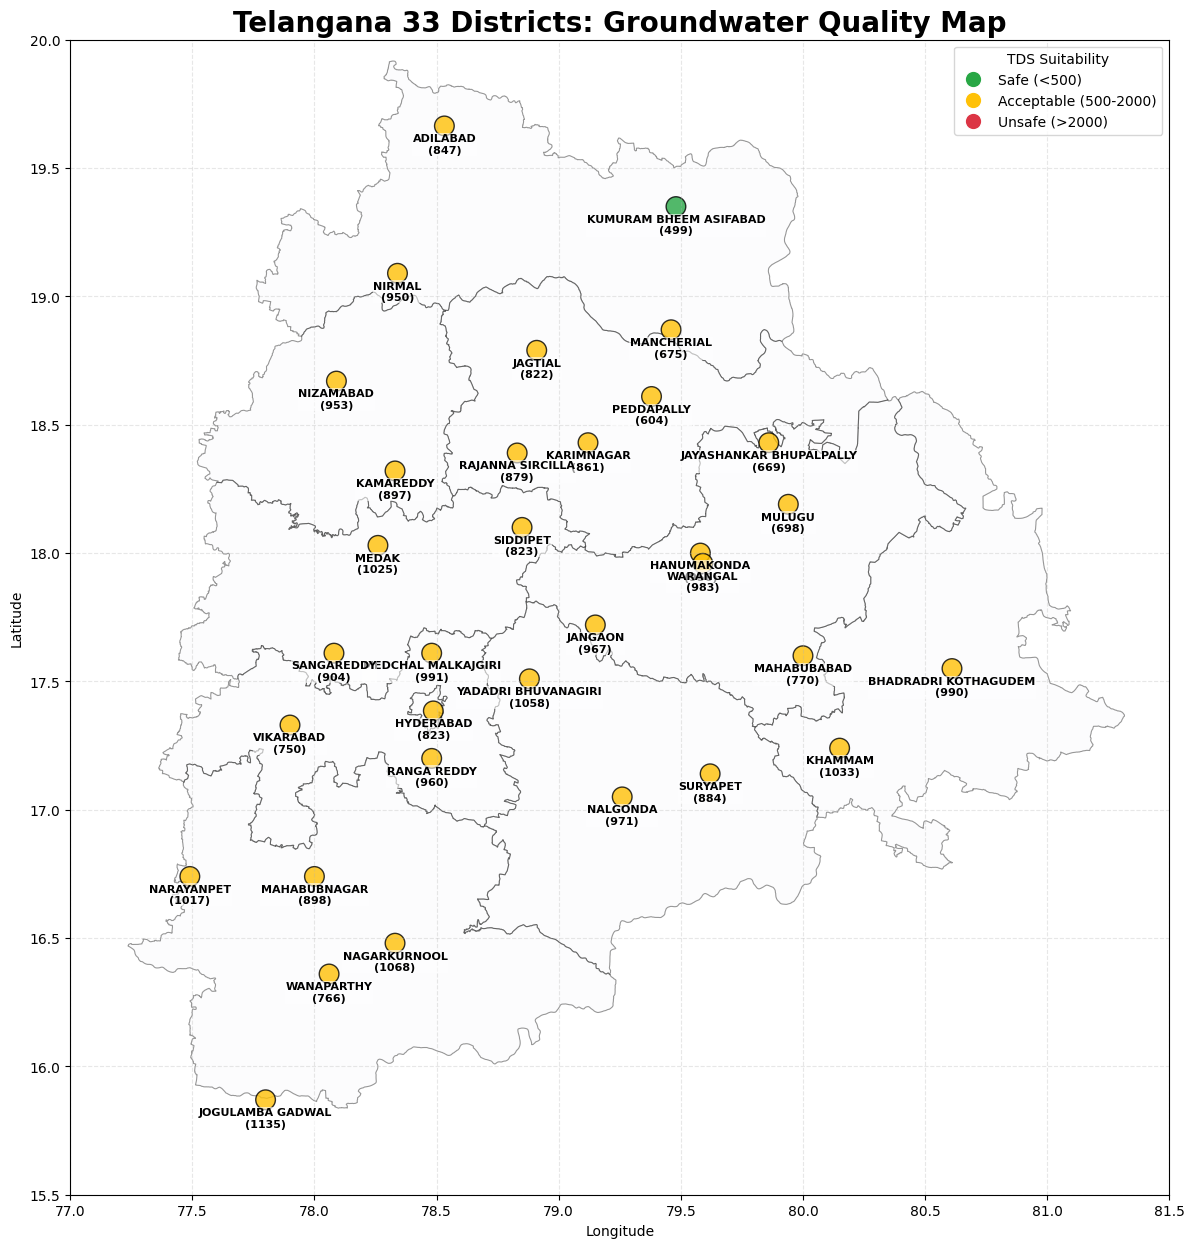

In [19]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

data = {
    'District': [
        'ADILABAD', 'BHADRADRI KOTHAGUDEM', 'HANUMAKONDA', 'HYDERABAD', 'JAGTIAL', 
        'JANGAON', 'JAYASHANKAR BHUPALPALLY', 'JOGULAMBA GADWAL', 'KAMAREDDY', 'KARIMNAGAR', 
        'KHAMMAM', 'KUMURAM BHEEM ASIFABAD', 'MAHABUBABAD', 'MAHABUBNAGAR', 'MANCHERIAL', 
        'MEDAK', 'MEDCHAL MALKAJGIRI', 'MULUGU', 'NAGARKURNOOL', 'NALGONDA', 
        'NARAYANPET', 'NIRMAL', 'NIZAMABAD', 'PEDDAPALLY', 'RAJANNA SIRCILLA', 
        'RANGA REDDY', 'SANGAREDDY', 'SIDDIPET', 'SURYAPET', 'VIKARABAD', 
        'WANAPARTHY', 'WARANGAL', 'YADADRI BHUVANAGIRI'
    ],
    'TDS': [
        847, 990, 956, 823, 822, 
        967, 669, 1135, 897, 861, 
        1033, 499, 770, 898, 675, 
        1025, 991, 698, 1068, 971, 
        1017, 950, 953, 604, 879, 
        960, 904, 823, 884, 750, 
        766, 983, 1058
    ]
}
df_plot = pd.DataFrame(data)

district_coords = {
    'ADILABAD': (19.6641, 78.5320),
    'BHADRADRI KOTHAGUDEM': (17.5500, 80.6100),
    'HANUMAKONDA': (18.0000, 79.5800),
    'HYDERABAD': (17.3850, 78.4867),
    'JAGTIAL': (18.7900, 78.9100),
    'JANGAON': (17.7200, 79.1500),
    'JAYASHANKAR BHUPALPALLY': (18.4300, 79.8600),
    'JOGULAMBA GADWAL': (15.8700, 77.8000), # Corrected for Gadwal town
    'KAMAREDDY': (18.3200, 78.3300),
    'KARIMNAGAR': (18.4300, 79.1200),
    'KHAMMAM': (17.2400, 80.1500),
    'KUMURAM BHEEM ASIFABAD': (19.3500, 79.4800),
    'MAHABUBABAD': (17.6000, 80.0000),
    'MAHABUBNAGAR': (16.7400, 78.0000),
    'MANCHERIAL': (18.8700, 79.4600),
    'MEDAK': (18.0300, 78.2600),
    'MEDCHAL MALKAJGIRI': (17.6100, 78.4800),
    'MULUGU': (18.1900, 79.9400),
    'NAGARKURNOOL': (16.4800, 78.3300),
    'NALGONDA': (17.0500, 79.2600),
    'NARAYANPET': (16.7400, 77.4900),
    'NIRMAL': (19.0900, 78.3400),
    'NIZAMABAD': (18.6700, 78.0900),
    'PEDDAPALLY': (18.6100, 79.3800),
    'RAJANNA SIRCILLA': (18.3900, 78.8300),
    'RANGA REDDY': (17.2000, 78.4800),
    'SANGAREDDY': (17.6100, 78.0800),
    'SIDDIPET': (18.1000, 78.8500),
    'SURYAPET': (17.1400, 79.6200),
    'VIKARABAD': (17.3300, 77.9000),
    'WANAPARTHY': (16.3600, 78.0600),
    'WARANGAL': (17.9600, 79.5900),
    'YADADRI BHUVANAGIRI': (17.5100, 78.8800)
}

df_plot['Lat'] = df_plot['District'].map(lambda x: district_coords.get(x, (0,0))[0])
df_plot['Lon'] = df_plot['District'].map(lambda x: district_coords.get(x, (0,0))[1])

def get_color(tds):
    if tds < 500: return '#28a745'       # Green
    elif tds <= 2000: return '#ffc107'   # Yellow
    else: return '#dc3545'               # Red

df_plot['Color'] = df_plot['TDS'].apply(get_color)

try:
    map_df = gpd.read_file('districts.json')
except:
    # Fallback if file is missing
    map_df = gpd.GeoDataFrame() 

fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Plot Background (if available)
if not map_df.empty:
    map_df.plot(ax=ax, color='#f8f9fa', edgecolor='black', linewidth=0.8, alpha=0.4)

ax.scatter(
    df_plot['Lon'], 
    df_plot['Lat'], 
    c=df_plot['Color'], 
    s=200,            # Larger dots for visibility
    alpha=0.8, 
    edgecolors='black'
)

for idx, row in df_plot.iterrows():
    label_text = f"{row['District']}\n({int(row['TDS'])})"
    
    # Adjust alignment to prevent some overlap if needed
    ax.text(
        row['Lon'], 
        row['Lat'] - 0.03,
        label_text, 
        fontsize=8, 
        ha='center', 
        va='top', 
        fontweight='bold',
        color='black',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0.5)
    )


legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#28a745', markersize=12, label='Safe (<500)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ffc107', markersize=12, label='Acceptable (500-2000)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#dc3545', markersize=12, label='Unsafe (>2000)'),
]
ax.legend(handles=legend_elements, loc='upper right', title="TDS Suitability")

ax.set_title('Telangana 33 Districts: Groundwater Quality Map', fontsize=20, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.3)

ax.set_xlim(77.0, 81.5)
ax.set_ylim(15.5, 20.0)

plt.show()

Loading data...
Generating Loss Graph...


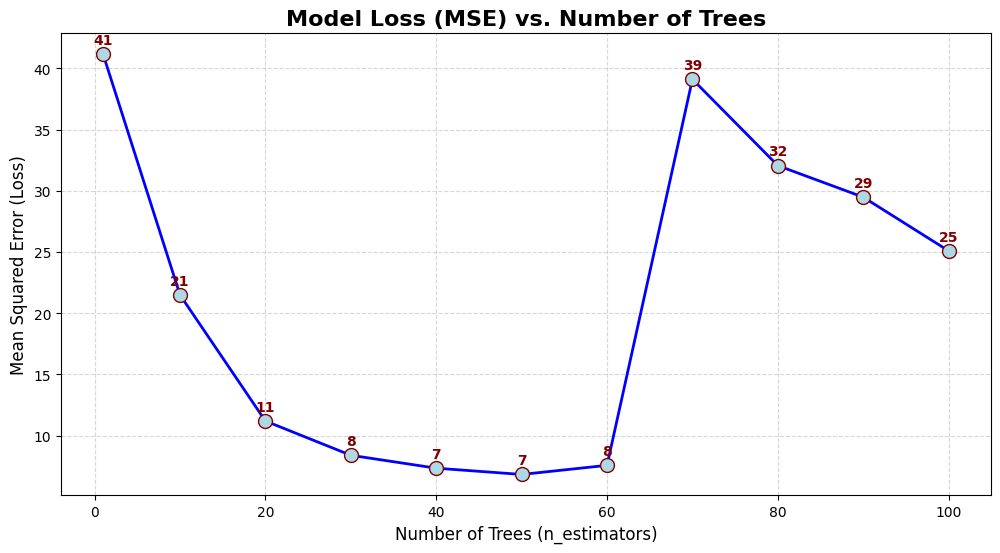

Generating Actual vs. Predicted Graph...


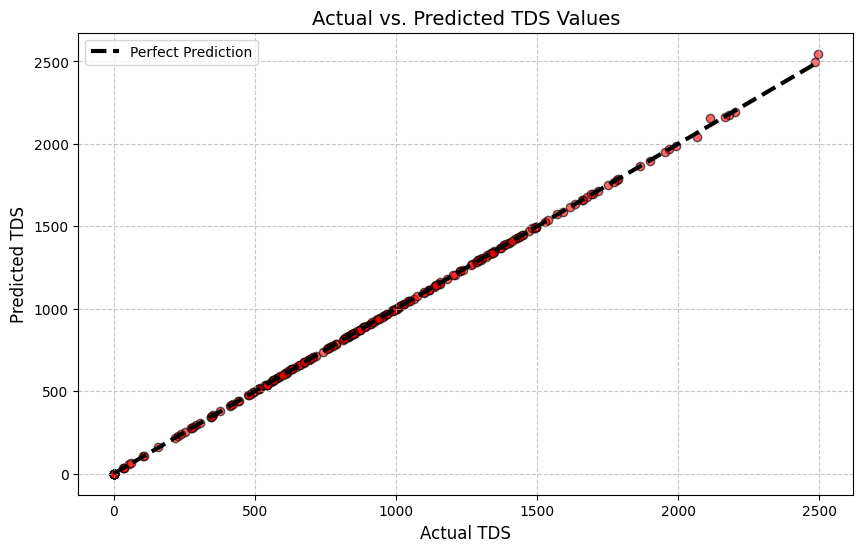

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

def load_data():
    try:
        print("Loading data...")
        df_train = pd.read_csv('water_quality_train.csv')
        df_test = pd.read_csv('water_quality_test.csv')
        df = pd.concat([df_train, df_test], ignore_index=True)
        return df
    except:
        print("⚠️ Files not found. Generating SYNTHETIC DATA for demonstration...")
        # Synthetic fallback
        np.random.seed(42)
        data = {
            'gwl': np.random.uniform(10, 100, 200),
            'pH': np.random.uniform(6.5, 8.5, 200),
            'E.C': np.random.uniform(500, 3000, 200),
            'F': np.random.uniform(0.5, 1.5, 200),
            'NO3': np.random.uniform(10, 50, 200),
            'TDS': np.random.uniform(500, 2500, 200)
        }
        return pd.DataFrame(data)

df = load_data()

# Clean & Prepare
df.columns = df.columns.str.strip()
features = ['gwl', 'pH', 'E.C', 'F', 'NO3']
target = 'TDS'

if 'NO3' not in df.columns and 'NO3 ' in df.columns:
    df.rename(columns={'NO3 ': 'NO3'}, inplace=True)

for col in features + [target]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(subset=features + [target], inplace=True)

X = df[features].values
y = df[target].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("Generating Loss Graph...")
mse_scores = []
n_trees_list = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

for n in n_trees_list:
    model = RandomForestRegressor(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mse_scores.append(mean_squared_error(y_test, preds))

plt.figure(figsize=(12, 6))

plt.plot(n_trees_list, mse_scores, marker='o', linestyle='-', color='blue', linewidth=2, label='MSE Loss')

plt.scatter(n_trees_list, mse_scores, color='#ADD8E6', s=100, zorder=3, edgecolors='#800000')

plt.title('Model Loss (MSE) vs. Number of Trees', fontsize=16, fontweight='bold')
plt.xlabel('Number of Trees (n_estimators)', fontsize=12)
plt.ylabel('Mean Squared Error (Loss)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
for i, txt in enumerate(mse_scores):
    # Annotate each point with its MSE value
    plt.text(n_trees_list[i], mse_scores[i] + (max(mse_scores)*0.02), 
             f"{txt:.0f}", 
             ha='center', fontsize=10, fontweight='bold', color='#800000')

plt.show()

print("Generating Actual vs. Predicted Graph...")
final_model = RandomForestRegressor(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='red', edgecolor='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3, label='Perfect Prediction')
plt.title('Actual vs. Predicted TDS Values', fontsize=14)
plt.xlabel('Actual TDS', fontsize=12)
plt.ylabel('Predicted TDS', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np
from flask import Flask, render_template_string, request
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')

def load_and_train():
    # Load your real data files
    df_train = pd.read_csv('water_quality_train.csv')
    df_test = pd.read_csv('water_quality_test.csv')
    df_full = pd.concat([df_train, df_test], ignore_index=True)
    
    # Clean column names
    df_full.columns = df_full.columns.str.strip()
    
    # Define features and target
    features = ['gwl', 'pH', 'E.C', 'F', 'NO3'] 
    target = 'TDS'
    
    if 'NO3' not in df_full.columns and 'NO3 ' in df_full.columns:
        df_full.rename(columns={'NO3 ': 'NO3'}, inplace=True)
        
    for col in features + [target]:
        df_full[col] = pd.to_numeric(df_full[col], errors='coerce')
    
    # Clean up data for training
    df_clean = df_full.dropna(subset=features + [target])
    X, y = df_clean[features].values, df_clean[target].values
    
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_scaled, y)
    
    return model, scaler, df_full

# Initialize
model, scaler_X, full_dataset = load_and_train()

css_styles = """
<style>
    body { font-family: 'Segoe UI', sans-serif; background: #f0f4f8; margin: 0; padding: 0; }
    .header { background: #1a237e; color: white; padding: 25px; text-align: center; }
    .container { max-width: 800px; margin: 30px auto; padding: 20px; }
    .card { background: white; border-radius: 12px; padding: 30px; box-shadow: 0 8px 16px rgba(0,0,0,0.05); margin-bottom: 25px; border-top: 5px solid #1a237e; }
    .btn { display: inline-block; padding: 15px 25px; color: white; border-radius: 8px; text-decoration: none; font-weight: bold; cursor: pointer; border: none; font-size: 16px; width: 75%; text-align: center; }
    .btn-blue { background: #1e88e5; } .btn-green { background: #43a047; } .btn-orange { background: #fb8c00; }
    .form-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 20px; }
    input { width: 100%; padding: 12px; border: 1px solid #ced4da; border-radius: 6px; font-size: 16px; box-sizing: border-box; }
    .result-section { margin-top: 30px; padding-top: 20px; border-top: 2px solid #e9ecef; }
    .mandal-badge { background: #e8eaf6; color: #1a237e; padding: 10px; border-radius: 6px; font-weight: bold; text-align: center; border: 1px solid #c5cae9; margin-bottom: 15px; }
    .metric-box { text-align: center; padding: 20px; background: #f8f9fa; border-radius: 10px; border: 1px solid #dee2e6; }
    .metric-val { font-size: 32px; font-weight: bold; color: #1a237e; }
    .badge { font-size: 20px; padding: 12px; border-radius: 8px; text-align: center; font-weight: bold; margin-top: 15px; }
    .bg-success { background-color: #d4edda; color: #155724; }
    .bg-warning { background-color: #fff3cd; color: #856404; }
    .bg-danger { background-color: #f8d7da; color: #721c24; }
</style>
"""

html_template = """
<!DOCTYPE html><html><head><title>{{ title }}</title>""" + css_styles + """</head><body>
<div class="header"><h1>💧 TELANGANA WATER PORTAL</h1><p>{{ title }}</p></div>
<div class="container"><div class="card">
    <form method="POST"><div class="form-grid">
        {% for field, label in fields.items() %}
        <div style="margin-bottom:15px;"><label style="display:block; font-weight:600; margin-bottom:5px;">{{ label }}</label>
        <input type="text" name="{{ field }}" value="{{ vals[field] }}" required></div>
        {% endfor %}
    </div><button type="submit" class="btn {{ btn_class }}">Run Analysis</button></form>
    
    {% if show_result %}
    <div class="result-section">
        <div class="mandal-badge">📍 Closest Matched Location: {{ matched_mandal }}, {{ matched_district }}</div>
        <div class="metric-box"><div>Predicted TDS Level</div><div class="metric-val">{{ tds_val }} mg/L</div></div>
        <div class="badge {{ status_bg }}">STATUS: {{ status_text }}</div>
    </div>
    {% endif %}
</div><a href="/" style="display:block; text-align:center; color:#546e7a; text-decoration:none;">← Back to Home</a></div></body></html>
"""

app = Flask(__name__)

fields = {'gwl': 'Ground Water Level (m)', 'pH': 'pH Value', 'ec': 'Electrical Conductivity (E.C)', 'f': 'Fluoride (F)', 'no3': 'Nitrate (NO3)'}

@app.route('/')
def home():
    return render_template_string("""<!DOCTYPE html><html><head><title>Home</title>""" + css_styles + """</head><body>
    <div class="header"><h1>HOME PAGE</h1><p>Water Analysis Portal</p></div>
    <div class="container">
        <div class="card"><h3>Groundwater Level Testing Status</h3><a href="/groundwater" class="btn btn-blue">Check Status →</a></div>
        <div class="card"><h3>Drinking Water Classification</h3><a href="/drinking" class="btn btn-green">Analyze Potability →</a></div>
        <div class="card"><h3>Irrigation Water Classification</h3><a href="/irrigation" class="btn btn-orange">Analyze Suitability →</a></div>
    </div></body></html>""")

def handle_request(mode, btn_class):
    ctx = {'title': mode, 'btn_class': btn_class, 'fields': fields, 'show_result': False, 'vals': {f: '' for f in fields}}
    if request.method == 'POST':
        try:
            # 1. Get user input
            raw_vals = [float(request.form[f]) for f in fields]
            ctx['vals'] = {f: request.form[f] for f in fields}
            
            # 2. Predict TDS
            X_in = scaler_X.transform([raw_vals])
            pred_tds = model.predict(X_in)[0]
            
            # 3. FIND CLOSEST MANDAL IN DATASET
            # We look for the row where the real TDS is closest to our predicted TDS
            diff = (full_dataset['TDS'] - pred_tds).abs()
            closest_row_idx = diff.idxmin()
            matched_mandal = full_dataset.loc[closest_row_idx, 'mandal']
            matched_district = full_dataset.loc[closest_row_idx, 'district']
            
            # 4. Determine Classification
            if pred_tds < 500: status_text, status_bg = "Safe", "bg-success"
            elif pred_tds <= 2000: status_text, status_bg = "Acceptable", "bg-warning"
            else: status_text, status_bg = "Unsafe", "bg-danger"
            
            ctx.update({
                'tds_val': f"{pred_tds:.2f}",
                'show_result': True,
                'matched_mandal': matched_mandal,
                'matched_district': matched_district,
                'status_text': status_text,
                'status_bg': status_bg
            })
        except Exception as e:
            print(f"Error: {e}")
            
    return render_template_string(html_template, **ctx)

@app.route('/groundwater', methods=['GET', 'POST'])
def gw(): return handle_request("Groundwater Status", "btn-blue")

@app.route('/drinking', methods=['GET', 'POST'])
def dr(): return handle_request("Drinking Water Classification", "btn-green")

@app.route('/irrigation', methods=['GET', 'POST'])
def ir(): return handle_request("Irrigation Suitability", "btn-orange")

if __name__ == '__main__':
    display(HTML('<div style="padding:20px; background:#e3f2fd; border-radius:10px; text-align:center;"><h2>🚀 App is Active!</h2><a href="http://127.0.0.1:5000/" target="_blank" style="font-size:20px; font-weight:bold; color:#0d47a1;">CLICK TO OPEN WEB INTERFACE</a></div>'))
    app.run(port=5000)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [19/Jun/2026 09:14:49] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [19/Jun/2026 09:14:49] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [19/Jun/2026 09:14:52] "GET /groundwater HTTP/1.1" 200 -
127.0.0.1 - - [19/Jun/2026 09:15:03] "GET / HTTP/1.1" 200 -
